<a href="https://colab.research.google.com/github/mukul-mschauhan/Machine-Learning-Projects/blob/master/House_Price_Prediction_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

**With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']= [20, 8]

In [ ]:
# Import the Data
train = pd.read_csv("/content/housetrain.csv")
test = pd.read_csv("/content/housetest.csv")

In [ ]:
train.shape, test.shape

((1460, 81), (1459, 80))

In [ ]:
# Combine the Data
combined = pd.concat([train, test], ignore_index =True)

# No of Columns
num_cols = combined.select_dtypes(include = np.number).columns


In [ ]:
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

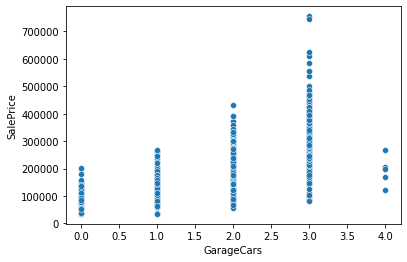

In [ ]:
# Lot Area is a good var for price
sns.scatterplot(combined.GarageCars, combined.SalePrice)

In [ ]:
# Check the Correlation
combined.loc[:, ["GarageCars", "SalePrice"]].corr()

,GarageCars,SalePrice
GarageCars,1.000000,0.640409
SalePrice,0.640409,1.000000


#### Observations

* Lot Area has 26% Correlation with Sale Price

* Overall Condition has the highest price at 5 rating. Overall Cond can be binned.

* Overall Quality has a very amazing pattern. It suggests that people are not interested in buying old and not so maintained properties.

* **GRLivArea** has 0.70 correlation & **GarageArea** has a 0.60 correlation

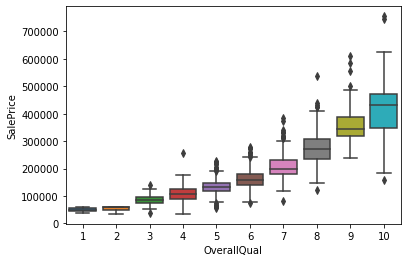

In [ ]:
# OverallQual vs Sales
sns.boxplot(x = "OverallQual", y = "SalePrice", data = combined)

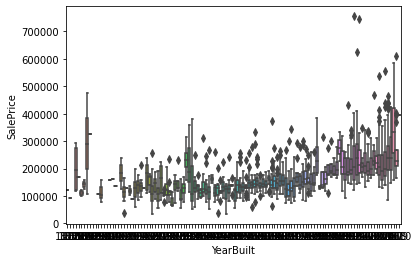

In [ ]:
# YearBuilt vs Sales
sns.boxplot(x = "YearBuilt", y = "SalePrice", data = combined)

In [ ]:
combined.YearBuilt.describe()

count    2919.000000
mean     1971.312778
std        30.291442
min      1872.000000
25%      1953.500000
50%      1973.000000
75%      2001.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [ ]:
def year_cat(x):
  if x<=1900:
    return("Vintage")
  elif(x<=2000):
    return("Old")
  else:
    return("New")

In [ ]:
combined["Year_Cat"] = combined.YearBuilt.apply(year_cat)

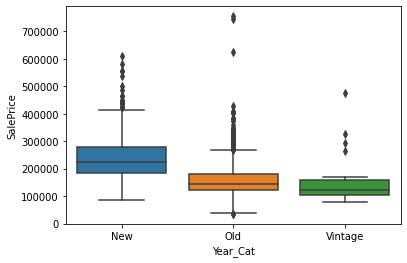

In [ ]:
sns.boxplot(x = "Year_Cat", y = "SalePrice", data = combined)

In [ ]:
# removing year var from the combined dataset
new = combined.drop(["Id", "YearBuilt", "PoolArea"], axis = 1)

In [ ]:
# Bin Garage Cars
def cars(x):
  if x==0:
    return("No_Garage")
  elif x<=2:
    return("Small_Garage")
  else:
    return("Big_Garage")

In [ ]:
# Binning Garage Cars
combined["Garage_Cars"] = combined.GarageCars.apply(cars)

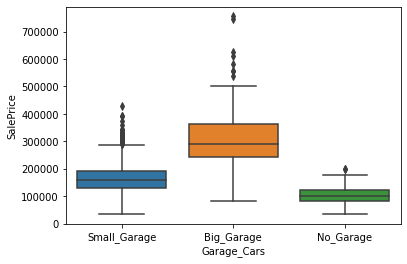

In [ ]:
# Plot the Garage  Cars
sns.boxplot(x = "Garage_Cars", y= "SalePrice", data = combined)

In [ ]:
# Garage Year

num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

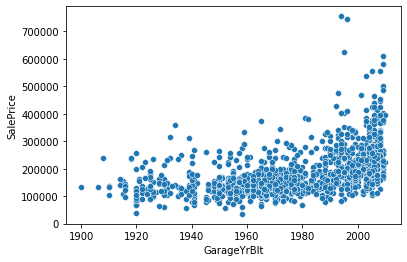

In [ ]:
sns.scatterplot(combined.GarageYrBlt, combined.SalePrice)

# Recently Built Garages have a very high sale price of the houses.

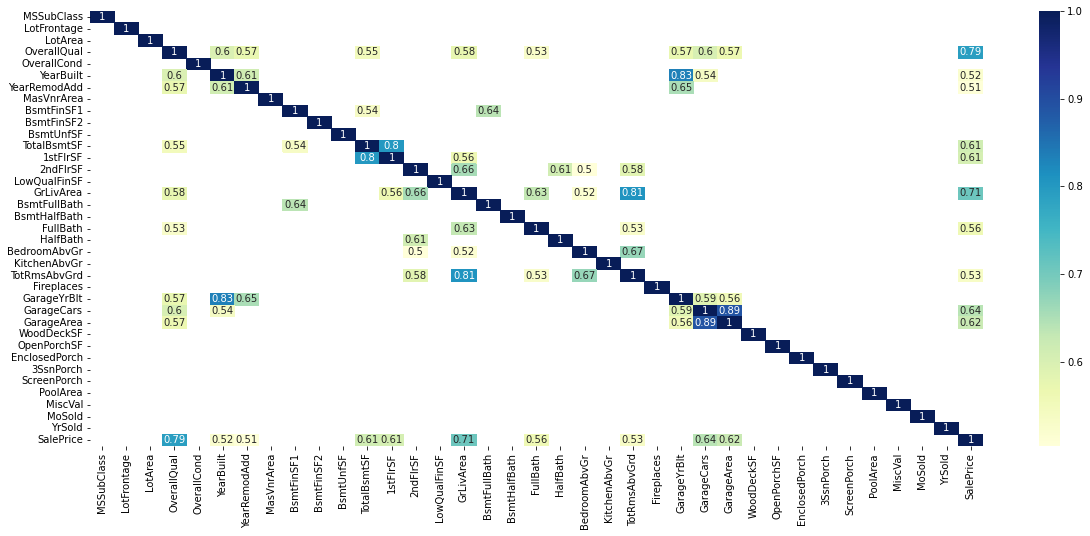

In [ ]:
# Heatmap
plt.figure(figsize = [20, 8])
sns.heatmap(combined.loc[:, num_cols[1:]].corr()[combined.loc[:, num_cols[1:]].corr()>0.50],
            annot = True, cmap = "YlGnBu")

In [ ]:
# Adding TotalBsmntSF, BsmntFinSF1 and so on...
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
combined["TotalSF"] = combined['BsmtFinSF1']+combined['BsmtFinSF2']+combined['BsmtUnfSF']+\
combined['TotalBsmtSF']+combined['1stFlrSF']+combined['2ndFlrSF']

In [ ]:
combined.select_dtypes(include = np.number).columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
new = combined.drop(["Id", "YearBuilt", "PoolArea", 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], axis = 1)

In [ ]:
new.select_dtypes(include = np.number).columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearRemodAdd', 'MasVnrArea', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'MoSold',
       'YrSold', 'SalePrice', 'TotalSF'],
      dtype='object')

In [ ]:
# Clustering
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
kmeans = KMeans(random_state = 2)
viz = KElbowVisualizer(estimator = kmeans)

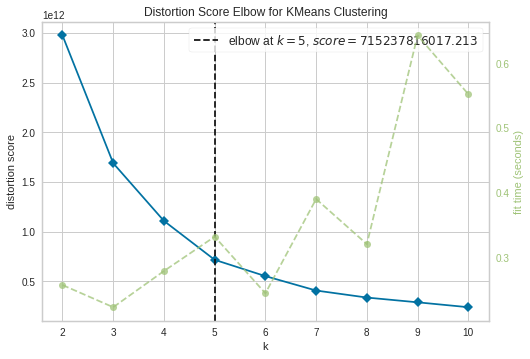

In [ ]:
viz.fit(new.select_dtypes(include = np.number).dropna())
viz.show()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Year_Cat,Garage_Cars
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,2,2008,WD,Normal,208500.0,New,Small_Garage
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,0,5,2007,WD,Normal,181500.0,Old,Small_Garage
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,0,9,2008,WD,Normal,223500.0,New,Small_Garage
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,Old,Big_Garage
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,0,12,2008,WD,Normal,250000.0,Old,Big_Garage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,6,2006,WD,Normal,NaN,Old,No_Garage
2915,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,4,2006,WD,Abnorml,NaN,Old,Small_Garage
2916,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,9,2006,WD,Abnorml,NaN,Old,Small_Garage
2917,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,MnPrv,Shed,700,7,2006,WD,Normal,NaN,Old,No_Garage


In [ ]:
# Applied Direct Visualization
# Note: Visualize the Whole Data in 2 Dim...after scaling
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

In [ ]:
pca_data = pd.DataFrame(pca.fit_transform(new.select_dtypes(include = np.number).dropna()), columns = ["PC1", "PC2"])

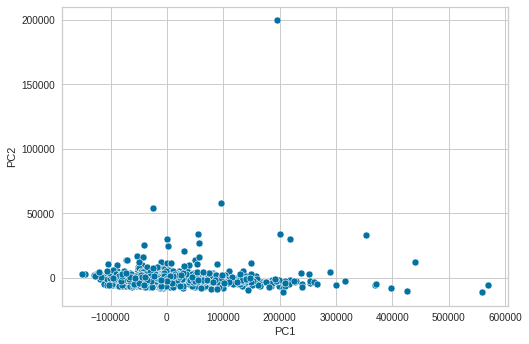

In [ ]:
sns.scatterplot(x = "PC1", y = "PC2", data = pca_data)
plt.show()

# We have created two dimension data where we two principal components
# that show up in the below plot.
# These two PCs have the max variance of the data.
# Because the data is very small and hence the two components have been
# found where the data has max variance.

In [ ]:
# Missing Values
miss = new.isnull().sum()[new.isnull().sum()!=0]
percent = miss/np.sum(miss)

pd.concat([miss, percent], axis = 1).sort_values(by = 1, ascending = False).index


Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'SalePrice', 'FireplaceQu',
       'LotFrontage', 'GarageQual', 'GarageFinish', 'GarageYrBlt',
       'GarageCond', 'GarageType', 'BsmtCond', 'BsmtExposure', 'BsmtQual',
       'BsmtFinType2', 'BsmtFinType1', 'MasVnrType', 'MasVnrArea', 'MSZoning',
       'BsmtHalfBath', 'Functional', 'BsmtFullBath', 'Utilities', 'SaleType',
       'KitchenQual', 'GarageArea', 'GarageCars', 'Electrical', 'Exterior2nd',
       'Exterior1st', 'TotalSF'],
      dtype='object')

In [ ]:
new_combo = new.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
       'LotFrontage', 'GarageQual', 'GarageFinish', 'GarageYrBlt',
       'GarageCond', 'GarageType', 'BsmtCond', 'BsmtExposure', 'BsmtQual',
       'BsmtFinType2', 'BsmtFinType1', 'MasVnrType', 'MasVnrArea', 'MSZoning',
       'BsmtHalfBath', 'Functional', 'BsmtFullBath', 'Utilities', 'SaleType',
       'KitchenQual', 'GarageArea', 'GarageCars', 'Electrical', 'Exterior2nd',
       'Exterior1st'], axis = 1)

In [ ]:
len(new_combo.columns)

45

In [ ]:
new_combo["Bath"] = new_combo["FullBath"]+new_combo["HalfBath"]

In [ ]:
new_combo.loc[:, ['Bath', 'BedroomAbvGr', 'KitchenAbvGr',
                   'TotRmsAbvGrd','Fireplaces', "SalePrice",
                  'FullBath', 'HalfBath']].corr()

,Bath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,SalePrice,FullBath,HalfBath
Bath,1.000000,0.398271,0.090856,0.578685,0.290959,0.568267,0.786640,0.734212
BedroomAbvGr,0.398271,1.000000,0.241182,0.669737,0.086793,0.168213,0.356125,0.245318
KitchenAbvGr,0.090856,0.241182,1.000000,0.294569,-0.107892,-0.135907,0.170958,-0.042691
TotRmsAbvGrd,0.578685,0.669737,0.294569,1.000000,0.311260,0.533723,0.527337,0.345572
Fireplaces,0.290959,0.086793,-0.107892,0.311260,1.000000,0.466929,0.235927,0.205876
SalePrice,0.568267,0.168213,-0.135907,0.533723,0.466929,1.000000,0.560664,0.284108
FullBath,0.786640,0.356125,0.170958,0.527337,0.235927,0.560664,1.000000,0.158386
HalfBath,0.734212,0.245318,-0.042691,0.345572,0.205876,0.284108,0.158386,1.000000


In [ ]:
# Dropping BedroomAbvGr as it is highly corr with TotalRmsAboveGrd
# Keeping TotalRmsAboveGrd as it has a higher correlation with TGT

new_combo = new_combo.drop(['BedroomAbvGr'], axis = 1)

In [ ]:
# Removing Full Batch and Half Bath
new_combo = new_combo.drop(['FullBath', 'HalfBath'], axis = 1)


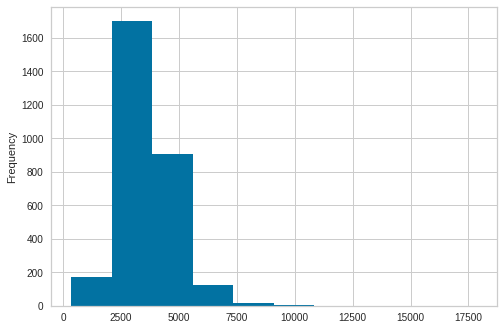

In [ ]:
new_combo.loc[:, "TotalSF"].plot(kind = 'hist')

In [ ]:
# Using Median to fill na values.
new_combo.TotalSF.fillna(new_combo.TotalSF.median(), inplace = True)

In [ ]:
# Cat Variables
new_combo.select_dtypes(include = "object").columns

Index(['Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation',
       'Heating', 'HeatingQC', 'CentralAir', 'PavedDrive', 'SaleCondition',
       'Year_Cat', 'Garage_Cars'],
      dtype='object')

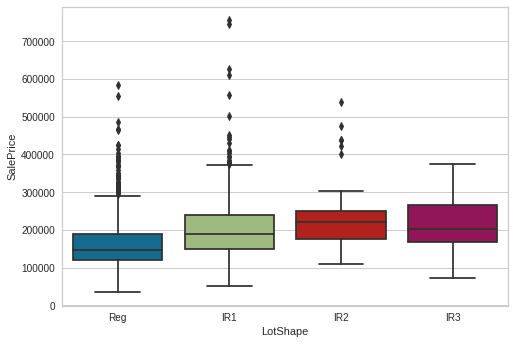

In [ ]:
# Street vs SalePrice
sns.boxplot(x = "LotShape", y = "SalePrice", data = new_combo)

In [ ]:
new_combo.Heating.value_counts()

GasA      2874
Others      45
Name: Heating, dtype: int64

In [ ]:
new_combo.Heating.replace(to_replace = ['GasW', 'Grav', 'Wall', 'OthW', 'Floor'],
                            value= ["Others"]*5, inplace = True)

In [ ]:
# Making Fair and Poor as one
new_combo.HeatingQC.replace(to_replace = ["Po"],
                            value= "Fa", inplace = True)

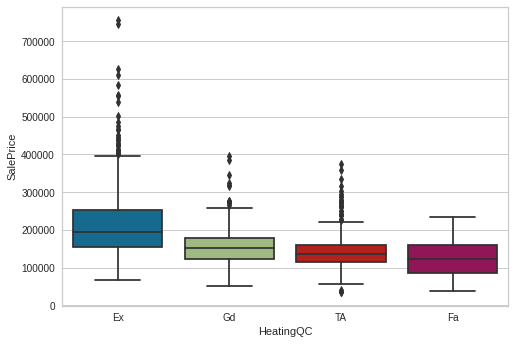

In [ ]:
sns.boxplot(x = "HeatingQC", y = "SalePrice", data = new_combo)

In [ ]:
cols = ['LandContour', 'LotConfig', 'LandSlope',
       'Neighbor_Cat', 'Condition1', 'BldgType',
       'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation',
        'CentralAir', 'PavedDrive', 'SaleCondition']

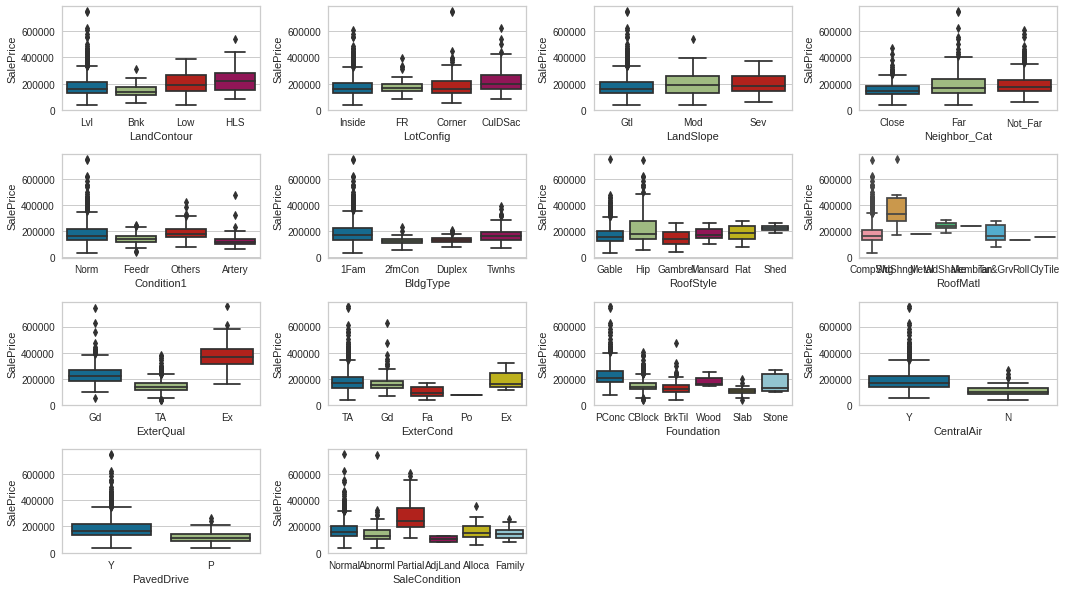

In [ ]:
a = 5
b = 4
c = 1
plt.figure(figsize=[15, 10])
for i in cols:
  plt.subplot(a, b, c)
  sns.boxplot(new_combo.loc[:, i], new_combo.SalePrice)
  plt.xlabel(i)
  c = c+1

plt.tight_layout()
plt.show()

In [ ]:
# Convert N into P in PavedDrive
new_combo.PavedDrive.replace(to_replace= "N",
                             value = "P", inplace = True)

In [ ]:
# Converting BNS into Low
new_combo.LandContour.replace(to_replace= "BnK",
                             value = "Low", inplace = True)

In [ ]:
# Lot Config:Fr2 and Fr3 =>
new_combo.LotConfig.value_counts()

new_combo.LotConfig.replace(to_replace=  ["FR2", "FR3"],
                            value = ["FR", "FR"],
                            inplace = True)

In [ ]:
# Neighborhood
map_dist = new_combo.Neighborhood.value_counts()/new_combo.Neighborhood.value_counts().sum()

new_combo["Neighbor_FE"] = new_combo.Neighborhood.map(map_dist)

In [ ]:
def neighbor(x):
  if x<0.04:
    return("Far")
  elif x<0.08:
    return("Not_Far")
  else:
    return("Close")

In [ ]:
new_combo["Neighbor_Cat"] = new_combo.Neighbor_FE.apply(neighbor)

In [ ]:
# Drop Neighborhood
new_combo = new_combo.drop("Neighborhood", axis = 1)

In [ ]:
# Condition1
new_combo.Condition1.value_counts().index[3:]

Index(['RRAn', 'PosN', 'RRAe', 'PosA', 'RRNn', 'RRNe'], dtype='object')

In [ ]:
new_combo.Condition1.replace(to_replace = ['RRAn', 'PosN', 'RRAe', 'PosA', 'RRNn', 'RRNe'],
                             value = ["Others"]*6, inplace = True)

In [ ]:
# Dropping Condition2 as it is same as Condition1
new_combo = new_combo.drop("Condition2", axis = 1)

In [ ]:
new_combo.Condition1.value_counts()

Norm      2511
Feedr      164
Others     152
Artery      92
Name: Condition1, dtype: int64

In [ ]:
new_combo.BldgType.value_counts()

1Fam      2425
TwnhsE     227
Duplex     109
Twnhs       96
2fmCon      62
Name: BldgType, dtype: int64

In [ ]:
# Convert Townhouse in 1
new_combo.BldgType.replace(to_replace = "TwnhsE", value = "Twnhs",
                           inplace = True)

In [ ]:
# ExterQual
new_combo.ExterQual.value_counts()

TA    1798
Gd     979
Ex     107
Fa      35
Name: ExterQual, dtype: int64

In [ ]:
# Convert FA into TA
new_combo.ExterQual.replace(to_replace = "Fa", value = "TA", inplace = True)

In [ ]:
# Housestyle
map_style = new_combo.HouseStyle.value_counts()/new_combo.HouseStyle.value_counts().sum()

In [ ]:
# lets map the housestyle
new_combo["House_Style"] = new_combo.HouseStyle.map(map_style)

In [ ]:
# Drop Housestyle
new_combo = new_combo.drop("HouseStyle", axis = 1)

In [ ]:
# Roofstyle
new_combo.RoofStyle.value_counts()

Gable      2310
Hip         551
Gambrel      22
Flat         20
Mansard      11
Shed          5
Name: RoofStyle, dtype: int64

In [ ]:
# Flat and Mansard as Flat
new_combo.RoofStyle.replace(to_replace  ="Mansard", value = "Flat", inplace = True)

# Hip, Gabel and Gambrel =>
new_combo.RoofStyle.replace(to_replace= ["Gable", "Gambrel"],
                            value = ["Hip", "Hip"], inplace = True)

In [ ]:
# Foundation
new_combo.Foundation.value_counts()

PConc     1308
CBlock    1235
BrkTil     311
Others      65
Name: Foundation, dtype: int64

In [ ]:
new_combo.Foundation.replace(to_replace = ["Slab", "Stone", "Wood"],
                  value = ["Others"]*3, inplace = True)

In [ ]:
# Sale Condition
new_combo.SaleCondition.value_counts()

Normal     2402
Partial     245
Abnorml     190
Family       46
Alloca       24
AdjLand      12
Name: SaleCondition, dtype: int64

In [ ]:
# Frequency Encoding
sale = new_combo.SaleCondition.value_counts()/new_combo.SaleCondition.value_counts().sum()

In [ ]:
new_combo["SaleCondition"] = new_combo.SaleCondition.map(sale)

# Modelling

In [ ]:
new_combo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 43 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   LotArea        2919 non-null   int64  
 2   Street         2919 non-null   object 
 3   LotShape       2919 non-null   object 
 4   LandContour    2919 non-null   object 
 5   LotConfig      2919 non-null   object 
 6   LandSlope      2919 non-null   object 
 7   Condition1     2919 non-null   object 
 8   BldgType       2919 non-null   object 
 9   OverallQual    2919 non-null   int64  
 10  OverallCond    2919 non-null   int64  
 11  YearRemodAdd   2919 non-null   int64  
 12  RoofStyle      2919 non-null   object 
 13  RoofMatl       2919 non-null   object 
 14  ExterQual      2919 non-null   object 
 15  ExterCond      2919 non-null   object 
 16  Foundation     2919 non-null   object 
 17  Heating        2919 non-null   object 
 18  HeatingQ

In [ ]:
new_combo.select_dtypes(include = 'int').head(2)

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,LowQualFinSF,GrLivArea,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MiscVal,MoSold,YrSold,Bath
0,60,8450,7,5,2003,0,1710,1,8,0,0,61,0,0,0,0,2,2008,3
1,20,9600,6,8,1976,0,1262,1,6,1,298,0,0,0,0,0,5,2007,2


In [ ]:
# EnclosedPorch	3SsnPorch	ScreenPorch and YearRemodAdd
finaldata = new_combo.drop(['EnclosedPorch',
                            '3SsnPorch', 'ScreenPorch','YearRemodAdd'], axis = 1)

In [ ]:
# Split the Data in Train and Test
new_train = finaldata.loc[0:train.shape[0]-1, ]
new_test = finaldata.loc[train.shape[0]:, ]

(1460, 81)

In [ ]:
# Drop the Tgt from New test
new_test = new_test.drop("SalePrice", axis = 1)

In [ ]:
new_train.shape, new_test.shape

((1460, 39), (1459, 38))

In [ ]:
# Dummify
dummytrain = pd.get_dummies(new_train, drop_first = True)
y = new_train.SalePrice

dummytest = pd.get_dummies(new_test, drop_first = True)

In [ ]:
dummytrain.shape, dummytest.shape

((1460, 68), (1459, 63))

In [ ]:
dummytrain.columns

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'LowQualFinSF',
       'GrLivArea', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF',
       'OpenPorchSF', 'MiscVal', 'MoSold', 'YrSold', 'SaleCondition',
       'SalePrice', 'TotalSF', 'Bath', 'Neighbor_FE', 'House_Style',
       'Street_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg',
       'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl',
       'LotConfig_CulDSac', 'LotConfig_FR', 'LotConfig_Inside',
       'LandSlope_Mod', 'LandSlope_Sev', 'Condition1_Feedr', 'Condition1_Norm',
       'Condition1_Others', 'BldgType_2fmCon', 'BldgType_Duplex',
       'BldgType_Twnhs', 'RoofStyle_Hip', 'RoofStyle_Shed', 'RoofMatl_CompShg',
       'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll',
       'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl',
       'ExterQual_Gd', 'ExterQual_TA', 'ExterCond_Fa', 'ExterCond_Gd',
       'ExterCond_Po', 'ExterCond_TA', 'Foundation_CBlock',
       'Foundation_

In [ ]:
dummytest.columns

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'LowQualFinSF',
       'GrLivArea', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF',
       'OpenPorchSF', 'MiscVal', 'MoSold', 'YrSold', 'SaleCondition',
       'TotalSF', 'Bath', 'Neighbor_FE', 'House_Style', 'Street_Pave',
       'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS',
       'LandContour_Low', 'LandContour_Lvl', 'LotConfig_CulDSac',
       'LotConfig_FR', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev',
       'Condition1_Feedr', 'Condition1_Norm', 'Condition1_Others',
       'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'RoofStyle_Hip',
       'RoofStyle_Shed', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake',
       'RoofMatl_WdShngl', 'ExterQual_Gd', 'ExterQual_TA', 'ExterCond_Fa',
       'ExterCond_Gd', 'ExterCond_Po', 'ExterCond_TA', 'Foundation_CBlock',
       'Foundation_Others', 'Foundation_PConc', 'Heating_Others',
       'HeatingQC_Fa', 'HeatingQC_Gd', 'HeatingQC_TA', 

In [ ]:
mycols = ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'LowQualFinSF',
       'GrLivArea', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF',
       'OpenPorchSF', 'MiscVal', 'MoSold', 'YrSold', 'SaleCondition',
       'TotalSF', 'Bath', 'Neighbor_FE', 'House_Style', 'Street_Pave',
       'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS',
       'LandContour_Low', 'LandContour_Lvl', 'LotConfig_CulDSac',
       'LotConfig_FR', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev',
       'Condition1_Feedr', 'Condition1_Norm', 'Condition1_Others',
       'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'RoofStyle_Hip',
       'RoofStyle_Shed', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake',
       'RoofMatl_WdShngl', 'ExterQual_Gd', 'ExterQual_TA', 'ExterCond_Fa',
       'ExterCond_Gd', 'ExterCond_Po', 'ExterCond_TA', 'Foundation_CBlock',
       'Foundation_Others', 'Foundation_PConc', 'Heating_Others',
       'HeatingQC_Fa', 'HeatingQC_Gd', 'HeatingQC_TA', 'CentralAir_Y',
       'PavedDrive_Y', 'Year_Cat_Old', 'Year_Cat_Vintage',
       'Garage_Cars_No_Garage', 'Garage_Cars_Small_Garage', 'Neighbor_Cat_Far',
       'Neighbor_Cat_Not_Far']

In [ ]:
for i in dummytrain.columns:
  if i not in mycols:
    print(i)

SalePrice
RoofMatl_CompShg
RoofMatl_Membran
RoofMatl_Metal
RoofMatl_Roll


In [ ]:
dummytrain = dummytrain.drop("SalePrice", axis = 1)

In [ ]:
dummytrain.shape, dummytest.shape

((1460, 63), (1459, 63))

In [ ]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
#from xgboost import XGBRegressor
#from lightgbm import LGBMRegressor

In [ ]:
# Build the Model
lr = LinearRegression()
rf = RandomForestRegressor()
ada = AdaBoostRegressor()
kabootar = GradientBoostingRegressor()


In [ ]:
pred_lr = lr.fit(dummytrain, y).predict(dummytest)
pred_rf = rf.fit(dummytrain, y).predict(dummytest)
pred_ada = ada.fit(dummytrain, y).predict(dummytest)
pred_gbm = kabootar.fit(dummytrain,y).predict(dummytest)

In [ ]:
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_lr})
solution.to_csv("LRMODEL.csv", index = False) # 0.21992

In [ ]:
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_rf})
solution.to_csv("RFMODEL.csv", index = False) # 0.15295


In [ ]:
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_ada})
solution.to_csv("ADAMODEL.csv", index = False) # 0.211


In [ ]:
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_gbm})
solution.to_csv("GBM_MODEL.csv", index = False) # 0.14324


In [ ]:
# Install Lightgbm
!pip install lightgbm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor()
pred_lgbm = lgbm.fit(dummytrain, y).predict(dummytest)

solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_lgbm})
solution.to_csv("LGBM_MODEL.csv", index = False) # 0.211

In [ ]:
# Tuning Gradient Boosting
from sklearn.model_selection import GridSearchCV
gbm = GradientBoostingRegressor()

params = [{'loss':['squared_error', 'absolute_error', 'huber', 'quantile'],
         'learning_rate':[0.1, 0.01, 0.12, 0.2, 0.5],
          'criterion':['friedman_mse', 'squared_error', 'mse'],
         'max_depth':[3,4,5,6]}]

rfs = GridSearchCV(estimator=gbm, param_grid=params)

rfs.fit(dummytrain, y)
print(rfs.best_params_)

{'criterion': 'mse', 'learning_rate': 0.2, 'loss': 'absolute_error', 'max_depth': 5}


In [ ]:
# Tuned Model - GBM
kabootar = GradientBoostingRegressor(criterion='mse',
                                     learning_rate= 0.2,
                                     loss='absolute_error', max_depth= 5)

In [ ]:
pred_gbm = kabootar.fit(dummytrain,y).predict(dummytest)
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_gbm})
solution.to_csv("ParaGBM_MODEL.csv", index = False) # 0.14249

In [ ]:
# PCA & GBM
pca = PCA(n_components = 2)
pca_train = pca.fit_transform(dummytrain)
pca_test = pca.transform(dummytest)
pred_pca = gbm.fit(pca_train, y).predict(pca_test)

solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_pca})
solution.to_csv("PCA_GBMMODEL.csv", index = False) # 0.25

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda=LDA()

In [ ]:
pred_lda = lda.fit(dummytrain,y).predict(dummytest)
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_lda})
solution.to_csv("LDA_MODEL.csv", index = False) # 0.23

In [ ]:
!pip install catboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 88 kB/s 


In [ ]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [ ]:
xgb = XGBRegressor()
cat = CatBoostRegressor()

pred_xgb = xgb.fit(dummytrain,y).predict(dummytest)
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_xgb})
solution.to_csv("XGB_MODEL.csv", index = False) # 0.1440

pred_cat = cat.fit(dummytrain,y).predict(dummytest)
solution = pd.DataFrame({"Id":test.Id, 'SalePrice': pred_cat})
solution.to_csv("CAT_MODEL.csv", index = False) # 0.1341

[12:25:18] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
Learning rate set to 0.043466
0:	learn: 77288.6890867	total: 51.3ms	remaining: 51.3s
1:	learn: 75106.7383629	total: 63.1ms	remaining: 31.5s
2:	learn: 73370.3323410	total: 70.3ms	remaining: 23.4s
3:	learn: 71286.5983685	total: 74.6ms	remaining: 18.6s
4:	learn: 69323.4694084	total: 81.1ms	remaining: 16.1s
5:	learn: 67723.6474597	total: 85.1ms	remaining: 14.1s
6:	learn: 65854.4742586	total: 98.4ms	remaining: 14s
7:	learn: 64222.9595396	total: 105ms	remaining: 13s
8:	learn: 62552.4641948	total: 108ms	remaining: 11.9s
9:	learn: 60957.9005688	total: 114ms	remaining: 11.3s
10:	learn: 59476.7144566	total: 117ms	remaining: 10.6s
11:	learn: 58062.6751229	total: 123ms	remaining: 10.1s
12:	learn: 56656.0601105	total: 127ms	remaining: 9.63s
13:	learn: 55307.0289688	total: 132ms	remaining: 9.33s
14:	learn: 54051.6534275	total: 136ms	remaining: 8.93s
15:	learn: 53029.6037223	

### Summary of Models

* Linear Regeression **RMSE 0.21992**
* Random Forest **RMSE 0.15295**
* AdaBoost Regressor **RMSE 0.220**
* Gradient Boosting Regressor **RMSE 0.14324**
* Gradient Boosting Parameter Tuned **RMSE 0.14249**
* PCA with GBM **RMSE 0.25106**
* Linear Discriminant Analysis **RMSE 0.2375**
* XGBoost **RMSE 0.14440**
* CatBoost: **RMSE 0.13431**
* Avg(XGB+CAT+GBM_TUNED): 0.1357
* Median(XGB+CAT+GBM_TUNED): 0.1366